# Namazi RAG walkthrough

I wrote this notebook to go through the project one step at a time, the same way I checked it myself:
books, chunks, index, search, evaluation, answers, tests. Every step prints something, so you can see with your own eyes whether it works.

Run it from the project folder (the one with `README.md`). It needs the index in `data/index`, which you get from `python -m scripts.ingest`.
You don't need an LLM to run it: section 10 uses a fake one, and section 11 only reads answers I saved earlier.

## 1. Setup

In [1]:
import logging
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

from app.config import get_settings

settings = get_settings()
print("embedding model:", settings.embedding_model)
print("books folder   :", settings.books_dir)
print("top_k           :", settings.top_k)
print("weights dense:bm25 =", settings.weight_dense, ":", settings.weight_bm25)

embedding model: BAAI/bge-m3
books folder   : data/books
top_k           : 5
weights dense:bm25 = 2.0 : 1.0


## 2. Load the books
The loader reads every PDF page by page. If a book has almost no words, it is probably a scan with no text layer,
so I count the words per book to catch that.

In [2]:
from app.loader import load_books

books = load_books(settings.books_dir)
table = pd.DataFrame(
    [{"book": name, "pages": len(pages), "words": sum(len(text.split()) for _, text in pages)}
     for name, pages in books.items()]
)
print(len(books), "books,", table["pages"].sum(), "pages,", table["words"].sum(), "words")
table.sort_values("words", ascending=False).reset_index(drop=True)

20 books, 2512 pages, 1419941 words


,book,pages,words
0,KDIGO 2021 Glomerular Diseases,281,152927
1,KDIGO 2024 CKD Guideline,199,148858
2,KDIGO 2012 CKD Evaluation and Management,162,124303
3,KDIGO 2009 Kidney Transplant Recipient Care,168,109863
4,KDIGO 2012 Acute Kidney Injury,141,103930
5,KDIGO 2022 Diabetes in CKD,128,90001
6,WHO Clinical Management of COVID-19,181,85405
7,KDIGO 2020 Kidney Transplant Candidate,106,84102
8,KDIGO 2012 Blood Pressure in CKD,85,71112
9,KDIGO 2026 Anemia in CKD,99,64888


Here is one raw page. PDF text is messy: a sign like >= often comes out as some odd letter.
That will matter later, when I search for exact numbers.

In [3]:
pages = dict(books["KDIGO 2012 Acute Kidney Injury"])
print(pages[10][:600])

Foreword
Kidney International Supplements (2012) 2, 7; doi:10.1038/kisup.2012.8
It is our hope that this document will serve several useful
purposes. Our primary goal is to improve patient care. We
hope to accomplish this, in the short term, by helping
clinicians know and better understand the evidence (or lack
of evidence) that determines current practice. By providing
comprehensive evidence-based recommendations, this guide-
line will also help deﬁne areas where evidence is lacking and
research is needed. Helping to deﬁne a research agenda is an
often neglected, but very important, function 


## 3. Chunking
Each chunk is about 250 words and stops at the end of a sentence. The last sentences of a chunk are repeated at the start of the next one
(an overlap of 50 words), so a fact that sits on the border doesn't get cut in half.

In [4]:
from app.chunking import chunk_pages

name = "KDIGO 2012 Acute Kidney Injury"
chunks = chunk_pages(name, books[name], settings.chunk_size, settings.chunk_overlap)
lengths = [len(c.text.split()) for c in chunks]
print(len(chunks), "chunks | words per chunk: min", min(lengths), "max", max(lengths),
      "average", round(sum(lengths) / len(lengths)))
print()
print("end of chunk 40  :", "...", chunks[40].text[-200:])
print("start of chunk 41:", chunks[41].text[:200], "...")

523

 chunks | words per chunk: min 33 max 250 average 234

end of chunk 40  : ... e is no unifying approach to the diagnosis and care of these patients. There is a worldwide need to recognize, detect, and intervene to circumvent the need for dialysis and to improve outcomes of AKI.
start of chunk 41: Importantly, there is no unifying approach to the diagnosis and care of these patients. There is a worldwide need to recognize, detect, and intervene to circumvent the need for dialysis and to improve ...


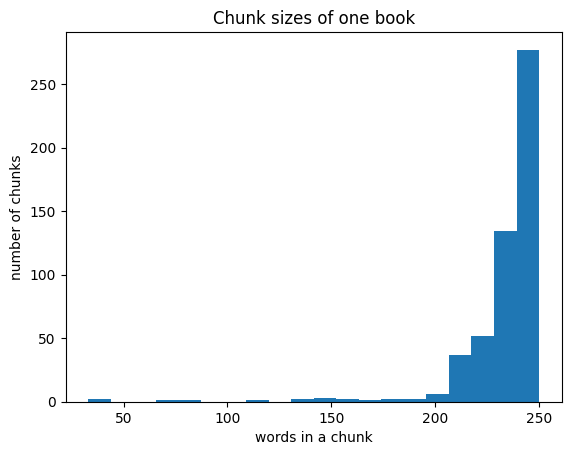

In [5]:
plt.hist(lengths, bins=20)
plt.xlabel("words in a chunk")
plt.ylabel("number of chunks")
plt.title("Chunk sizes of one book")
plt.show()

## 4. Load the index
I built the index earlier with `python -m scripts.ingest`. Loading it also builds the BM25 part in memory.

In [6]:
from app.embedder import make_embedder, make_reranker
from app.index import Index

embedder = make_embedder(settings)
reranker = make_reranker(settings)  # re-orders the best 20 chunks, the app uses it too
index = Index.load(settings.index_dir, settings.embedding_model, settings.bm25_k1, settings.bm25_b)

print("chunks:", len(index), "| vector size:", index.meta["dim"], "| built at:", index.meta["created_at"])
chunks_per_book = pd.Series([c.book for c in index.chunks]).value_counts()
chunks_per_book

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 20203.68it/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 7856.37it/s]

chunks: 7112 | vector size: 1024 | built at: 2026-10-08 21:42:53


KDIGO 2021 Glomerular Diseases                 758
KDIGO 2024 CKD Guideline                       744
KDIGO 2012 CKD Evaluation and Management       620
KDIGO 2009 Kidney Transplant Recipient Care    540
KDIGO 2012 Acute Kidney Injury                 523
KDIGO 2022 Diabetes in CKD                     453
WHO Clinical Management of COVID-19            432
KDIGO 2020 Kidney Transplant Candidate         418
KDIGO 2012 Blood Pressure in CKD               353
KDIGO 2026 Anemia in CKD                       327
WHO Malaria Diagnostic Testing Manual          301
KDIGO 2018 Hepatitis C in CKD                  252
KDIGO 2012 Anemia in CKD                       230
WHO mhGAP Intervention Guide v2                219
WHO Systematic Screening for Tuberculosis      206
WHO Meningitis Guidelines                      198
KDIGO 2017 CKD Mineral and Bone Disorder       185
KDIGO 2013 Lipid Management in CKD             166
WHO Child Health Recommendations               105
GOLD COPD Pocket Guide 2024    

## 5. Search
I search the same question four ways: by meaning only (dense), by exact words only (BM25), both together (hybrid, merged with Reciprocal Rank Fusion),
and hybrid plus a **reranker**: a second model that re-orders the 20 best chunks. The last one is what the app uses.

In [7]:
from app.retriever import HybridRetriever, RetrievalParams


def make_retriever(weight_dense, weight_bm25, top_k=5, rrf_k=None, rerank=False):
    params = RetrievalParams(top_k, settings.oversample, rrf_k or settings.rrf_k, weight_dense, weight_bm25)
    return HybridRetriever(index, embedder, params, reranker if rerank else None)


modes = [("dense only", 1, 0, False), ("BM25 only", 0, 1, False), ("hybrid 1:1", 1, 1, False), ("hybrid 2:1", 2, 1, False),
         ("hybrid 2:1 + reranker (the app)", 2, 1, True)]
question = "When should the metformin dose be reduced in CKD?"
print("Question:", question)
for mode_name, w_dense, w_bm25, rerank in modes:
    print("\n" + mode_name)
    for hit in make_retriever(w_dense, w_bm25, rerank=rerank).search(question):
        print(f"  {hit.score:.4f}  {hit.chunk.book}, page {hit.chunk.page}")

Question: When should the metformin dose be reduced in CKD?

dense only


  0.0164  KDIGO 2022 Diabetes in CKD, page 80
  0.0161  KDIGO 2012 CKD Evaluation and Management, page 25
  0.0159  KDIGO 2022 Diabetes in CKD, page 82
  0.0156  KDIGO 2012 CKD Evaluation and Management, page 114
  0.0154  KDIGO 2022 Diabetes in CKD, page 78

BM25 only
  0.0164  KDIGO 2022 Diabetes in CKD, page 80
  0.0161  KDIGO 2022 Diabetes in CKD, page 80
  0.0159  KDIGO 2022 Diabetes in CKD, page 27
  0.0156  KDIGO 2022 Diabetes in CKD, page 125
  0.0154  KDIGO 2022 Diabetes in CKD, page 82

hybrid 1:1
  0.0328  KDIGO 2022 Diabetes in CKD, page 80
  0.0302  KDIGO 2022 Diabetes in CKD, page 80
  0.0294  KDIGO 2022 Diabetes in CKD, page 27
  0.0293  KDIGO 2022 Diabetes in CKD, page 78
  0.0284  KDIGO 2022 Diabetes in CKD, page 78

hybrid 2:1
  0.0492  KDIGO 2022 Diabetes in CKD, page 80
  0.0447  KDIGO 2022 Diabetes in CKD, page 78
  0.0443  KDIGO 2022 Diabetes in CKD, page 80
  0.0434  KDIGO 2022 Diabetes in CKD, page 78
  0.0429  KDIGO 2022 Diabetes in CKD, page 27

hybrid 2:1 + r

  0.0447  KDIGO 2022 Diabetes in CKD, page 78
  0.0323  KDIGO 2012 CKD Evaluation and Management, page 25
  0.0312  KDIGO 2012 CKD Evaluation and Management, page 114
  0.0290  KDIGO 2022 Diabetes in CKD, page 81
  0.0429  KDIGO 2022 Diabetes in CKD, page 27


This is how the merge works. Each search gives a ranking. A chunk earns `weight / (k + rank)` points from each ranking, and the points add up.
Only the ranks are used, so the two score scales never have to match.
Here is a tiny example with made-up chunk numbers:

In [8]:
from app.retriever import rrf_fuse

dense_ranking = [1, 2, 3]   # chunk numbers, best first
bm25_ranking = [3, 1, 4]
print(rrf_fuse([dense_ranking, bm25_ranking], [1, 1], k=60))

[(1, 0.03252247488101534), (3, 0.032266458495966696), (2, 0.016129032258064516), (4, 0.015873015873015872)]


Chunks 1 and 3 are in both lists, so they end up on top. Chunks 2 and 4 are only in one list.

## 6. Evaluation
`data/eval/eval_questions.jsonl` has 141 questions: 76 English and 65 Persian. For each one I wrote a short phrase that has to appear in the right chunk.
Hit rate asks "is the right chunk in the top 5?" and MRR asks "how high did it rank?".
34 of the questions can't be answered from the books at all (their evidence is null). 36 of the Persian questions are the Persian version of an English one,
so the same fact can be compared in both languages.
I split the questions 70/30 into a dev part and a test part with a fixed seed, exactly like `scripts/tune.py` does.

In [9]:
from scripts.tune import evaluate, load_eval, split_eval

items = load_eval("data/eval/eval_questions.jsonl")
dev, test = split_eval(items, 42)
print(len(items), "questions:", len(dev), "dev,", len(test), "test")

rows = []
for mode_name, w_dense, w_bm25, rerank in modes:
    retriever = make_retriever(w_dense, w_bm25, rerank=rerank)
    for part_name, part in [("dev", dev), ("test", test), ("all", items)]:
        result = evaluate(retriever, part, 5)
        rows.append({"mode": mode_name, "questions": part_name, "n": result["n"],
                     "hit_rate@5": round(result["hit_rate"], 3), "mrr": round(result["mrr"], 3)})
results = pd.DataFrame(rows)
results.pivot(index="mode", columns="questions", values=["hit_rate@5", "mrr"])

141 questions: 98 dev, 43 test


hit_rate@5                  mrr              
questions                              all    dev   test    all    dev   test
mode                                                                         
BM25 only                            0.449  0.467  0.406  0.332  0.347  0.297
dense only                           0.729  0.747  0.688  0.544  0.595  0.425
hybrid 1:1                           0.766  0.747  0.812  0.571  0.594  0.519
hybrid 2:1                           0.766  0.760  0.781  0.568  0.598  0.499
hybrid 2:1 + reranker (the app)      0.888  0.880  0.906  0.776  0.791  0.742

The test part has very few answerable questions, so its numbers jump around.
I show the "all" columns too, but remember that I picked the settings on the dev part only.

## 7. The settings I tried
`python -m scripts.tune` tried 33 settings with the embedding model bge-m3 (no reranker): 3 chunk sizes, 5 dense/BM25 mixes and 3 RRF constants.
Below is the table it saved. It would pick 150-word chunks, but with the reranker 150, 200 and 250 words are within noise (I tested that), so I kept 250.

In [10]:
tuning = pd.read_csv("docs/tuning_results.csv")
print(len(tuning), "settings tried")
tuning.head(10)

33 settings tried


,chunk_size,overlap,weight_dense,weight_bm25,rrf_k,n_chunks,dev_hit_rate,dev_mrr
0,150,30,2,1,20,11891,0.8133,0.6442
1,150,30,1,1,60,11891,0.8133,0.6422
2,150,30,1,1,20,11891,0.8133,0.6422
3,150,30,1,1,100,11891,0.8133,0.6422
4,400,80,1,2,60,4448,0.7200,0.6422
5,400,80,1,2,100,4448,0.7200,0.6422
6,150,30,2,1,60,11891,0.8133,0.6418
7,150,30,2,1,100,11891,0.8133,0.6418
8,150,30,1,0,60,11891,0.8000,0.6389
9,400,80,1,2,20,4448,0.7067,0.6378


best MRR per chunk size:
             dev_hit_rate  dev_mrr
chunk_size                       
150               0.8133   0.6442
250               0.7733   0.6044
400               0.7467   0.6422 

best MRR per dense:bm25 mix:
 weight_dense  weight_bm25
0             1              0.3931
1             0              0.6389
              1              0.6422
              2              0.6422
2             1              0.6442
Name: dev_mrr, dtype: float64 

best MRR per rrf_k:
 rrf_k
20     0.6442
60     0.6422
100    0.6422
Name: dev_mrr, dtype: float64


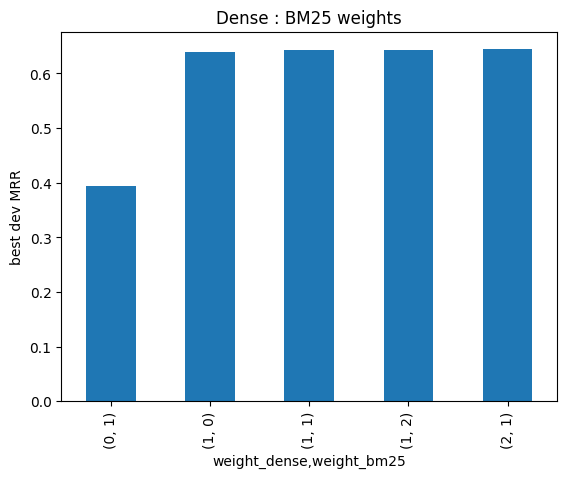

In [11]:
by_chunk = tuning.groupby("chunk_size")[["dev_hit_rate", "dev_mrr"]].max()
by_mix = tuning.groupby(["weight_dense", "weight_bm25"])["dev_mrr"].max()
by_rrf = tuning.groupby("rrf_k")["dev_mrr"].max()
print("best MRR per chunk size:\n", by_chunk, "\n")
print("best MRR per dense:bm25 mix:\n", by_mix, "\n")
print("best MRR per rrf_k:\n", by_rrf)

by_mix.plot(kind="bar")
plt.ylabel("best dev MRR")
plt.title("Dense : BM25 weights")
plt.show()

## 8. Where does it fail?
For every answerable question I look at where the right chunk lands in the search of the app (hybrid + reranker, top 20).
"NaN" means it isn't in the top 20 at all.

In [12]:
from scripts.tune import norm

retriever = make_retriever(settings.weight_dense, settings.weight_bm25, top_k=20, rerank=True)  # the app's search
rows = []
for item in items:
    if not item["evidence"]:
        continue
    hits = retriever.search(item["question"], 20)
    rank = next((n for n, hit in enumerate(hits, 1) if norm(item["evidence"]) in norm(hit.chunk.text)), None)
    rows.append({"question": item["question"][:60], "persian": not item["question"].isascii(), "rank": rank})
ranks = pd.DataFrame(rows)

english = ranks[~ranks["persian"]]
persian = ranks[ranks["persian"]]
print("English: in top 5 ->", (english["rank"] <= 5).sum(), "of", len(english))
print("Persian: in top 5 ->", (persian["rank"] <= 5).sum(), "of", len(persian))
ranks[ranks["rank"].isna() | (ranks["rank"] > 1)]

English: in top 5 -> 54 of 58
Persian: in top 5 -> 41 of 49


,question,persian,rank
0,How is acute kidney injury defined?,False,6.0
1,At what haemoglobin level is anaemia diagnosed...,False,2.0
4,How is chronic kidney disease defined?,False,4.0
6,When should the metformin dose be reduced in CKD?,False,2.0
7,Should a lipid profile be checked in adults wi...,False,2.0
8,Should all patients with CKD be screened for h...,False,3.0
9,Which immunosuppressive drugs are used for mai...,False,2.0
21,What is the target INR for a patient on warfarin?,False,5.0
22,Which type of contrast media is recommended fo...,False,2.0
31,Which prophylaxis should be considered in pati...,False,NaN


Here the Persian question goes into the search exactly as it was typed, and the right passage is in the top 5 for 41 of 49 questions (English: 54 of 58).
The real app also asks the LLM to translate the question into English first. With that step 45 of 49 Persian questions get the right passage into the sources (see section 11).
Persian is still behind English, but the new embedding model and the reranker closed most of the gap (before: 15 of 49).

## 9. Can we tell when the books have no answer?
`MIN_DENSE_SCORE` would skip the LLM whenever the best similarity is low. To see if that could work,
I compare the best similarity of the answerable and the unanswerable questions.

            count    min      mean    max
answerable                               
False        34.0  0.453  0.548706  0.605
True        107.0  0.442  0.660738  0.809


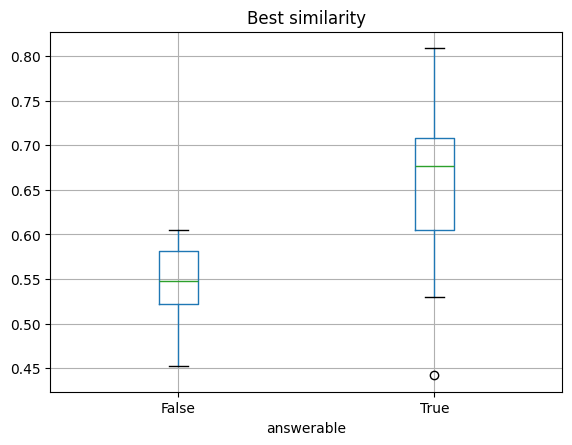

In [13]:
retriever = make_retriever(settings.weight_dense, settings.weight_bm25, top_k=5, rerank=True)
rows = []
for item in items:
    best = max(hit.dense_score for hit in retriever.search(item["question"], 5))
    rows.append({"answerable": bool(item["evidence"]), "best_similarity": round(best, 3)})
scores = pd.DataFrame(rows)
print(scores.groupby("answerable")["best_similarity"].describe()[["count", "min", "mean", "max"]])

scores.boxplot(column="best_similarity", by="answerable")
plt.suptitle("")
plt.title("Best similarity")
plt.show()

The two groups overlap. Answerable questions go as low as 0.44 and unanswerable ones as high as 0.61,
so a cutoff would either block real questions or let unanswerable ones through. That is why I left `MIN_DENSE_SCORE` at 0
and let the `NO_ANSWER` rule in the prompt decide. (The Persian questions are untranslated here, so a few Persian scores are lower than in the real app.)

## 10. The answer step (with a fake LLM)
You don't need an API key here. The fake LLM just returns whatever text I give it, so I can see the prompt that would be sent
and how the app handles the reply. The log lines show what happens inside.

In [14]:
from app.llm import LLMResult
from app.rag import RagService


class FakeLLM:
    def __init__(self, reply):
        self.reply = reply
        self.last_prompt = ""

    def complete(self, system, user):
        self.last_prompt = user
        return LLMResult(self.reply, prompt_tokens=1500, completion_tokens=40)


logging.basicConfig(level=logging.INFO, format="%(name)s: %(message)s", force=True)
for noisy in ("httpx", "sentence_transformers", "urllib3", "filelock"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

llm = FakeLLM("Dexamethasone is the preferred corticosteroid [1].")
rag = RagService(make_retriever(settings.weight_dense, settings.weight_bm25), llm)

answer = rag.ask("Which corticosteroid is preferred in bacterial meningitis?")
print("\nanswered:", answer.answered)
print("answer  :", answer.answer)
for number, hit in enumerate(answer.sources, 1):
    print(f"  [{number}] {hit.chunk.book}, page {hit.chunk.page}")
print("\nstart of the prompt sent to the LLM:\n", llm.last_prompt[:400])

app.rag: search found 5 chunks, best similarity 0.706


app.rag: sending 5 sources (8894 characters) to the LLM


app.rag: answered with 5 sources



answered: True
answer  : Dexamethasone is the preferred corticosteroid [1].
  [1] WHO Meningitis Guidelines, page 76
  [2] WHO Meningitis Guidelines, page 75
  [3] WHO Meningitis Guidelines, page 23
  [4] WHO Meningitis Guidelines, page 22
  [5] WHO Meningitis Guidelines, page 74

start of the prompt sent to the LLM:
 SOURCES:
[1] (WHO Meningitis Guidelines, page 76)
The above recommendations on the use of corticosteroids as adjunctive treatment for suspected acute bacterial meningitis also apply to people living with HIV who are on antiretroviral therapy and have undetectable viral load (less than 50 copies/μl). Intravenous corticosteroids administered as adjunctive treatment for suspected acute bacterial meni


In [15]:
# the model says it cannot answer, even with an extra sentence after NO_ANSWER
llm.reply = "NO_ANSWER. The sources do not mention this."
answer = rag.ask("What is the target INR for a patient on warfarin?")
print("\nanswered:", answer.answered)
print("answer  :", answer.answer)

app.rag: search found 5 chunks, best similarity 0.616


app.rag: sending 5 sources (7345 characters) to the LLM


app.rag: the LLM found no answer in the sources



answered: False
answer  : I could not find the answer to this question in the hospital's reference books. پاسخ این پرسش در منابع موجود پیدا نشد.


To try a real LLM, put the `LLM_*` settings in `.env` and start the API with `uvicorn app.main:app_factory --factory`.
Then call `POST /v1/ask` like the README shows.

## 11. Answer check with a real LLM
I ran all 141 questions through the whole pipeline with `python -m scripts.check_answers --judge`, using a real local model
(`qwen2.5:32b-instruct` in Ollama, context 8192) and the final search (bge-m3 + reranker). The answers are saved in `docs/answer_check.csv`.
This is not the fake LLM from section 10. These are saved results, so the notebook itself doesn't need the LLM.

In [16]:
check = pd.read_csv("docs/answer_check.csv")
check["language"] = ["English" if q.isascii() else "Persian" for q in check["question"]]

rows = []
for language, part in check.groupby("language"):
    good = part[part["answerable"]]
    bad = part[~part["answerable"]]
    rows.append({
        "language": language,
        "answerable questions": len(good),
        "gave an answer": int(good["answered"].sum()),
        "has a citation": int(good["has_citation"].sum()),
        "right passage in sources": int(good["evidence_in_sources"].sum()),
        "right passage cited": int(good["evidence_cited"].sum()),
        "unanswerable questions": len(bad),
        "correctly said not found": int((~bad["answered"]).sum()),
        "seconds per question": round(part["seconds"].mean(), 1),
    })
pd.DataFrame(rows).set_index("language").T

language,English,Persian
answerable questions,58.0,49.0
gave an answer,58.0,48.0
has a citation,58.0,48.0
right passage in sources,56.0,45.0
right passage cited,52.0,41.0
unanswerable questions,18.0,16.0
correctly said not found,18.0,16.0
seconds per question,3.7,4.9


The worst mistake is answering a question the books can't answer. These are the cases:

In [17]:
wrong = check[(~check["answerable"]) & check["answered"]]
print(len(wrong), "unanswerable question(s) still got an answer\n")
for _, row in wrong.iterrows():
    print(row["question"])
    print(row["answer"][:400])

0 unanswerable question(s) still got an answer



With the final setup **no question the books cannot answer got an answer**, in English or in Persian.
Before the upgrade (e5 embeddings, no reranker, longer prompt) two Persian ones did: eczema (built from a permethrin passage about scabies) and snake bite (with broken words in it).
Persian answers can still have awkward or broken wording, so a Persian answer should always be read with the English source next to it.

In [18]:
missed = check[check["answerable"] & ~check["evidence_cited"]].copy()
print(len(missed), "answerable questions where the right passage was not cited\n")
missed["question"] = missed["question"].str[:75]
missed[["question", "evidence_in_sources", "answered"]].reset_index(drop=True)

14 answerable questions where the right passage was not cited



,question,evidence_in_sources,answered
0,How is acute kidney injury defined?,False,True
1,What is the most characteristic symptom of COPD?,True,True
2,How should blood films be prepared for malaria...,False,True
3,What are delusions?,True,True
4,What is chest radiography used for after initi...,True,True
5,Which calcineurin inhibitor is suggested as fi...,True,True
6,بیماری شدید سیتومگالوویروس در گیرنده پیوند کلی...,True,False
7,برای بیماران در معرض نفروپاتی ناشی از ماده حاج...,False,True
8,آیا در بزرگسالان مبتلا به بیماری مزمن کلیه اند...,True,True
9,لام‌های خون برای میکروسکوپی مالاریا چگونه باید...,False,True


Whenever the right passage was in the sources but not cited, the model cited another passage that says almost the same thing.
A doctor has to read these rows and decide whether the answer is still right.
Also, two runs with the same settings don't give identical answers (70 of 93 were the same, and the number of right citations moved by 1),
so a difference of one or two questions means nothing.

## 12. Speed and answer quality in a few plots
Everything here comes from the real model run in section 11 (`docs/answer_check.csv`, one question at a time) and the load tests (`docs/load_test_results.csv`). The only thing measured live in this notebook is the search time.

### Search alone
How long does the whole search take before the LLM is even asked? (embedding the question + dense + BM25 + merge + reranker)

In [19]:
import time

retriever = make_retriever(settings.weight_dense, settings.weight_bm25, rerank=True)  # the whole search of the app
english_questions = [item["question"] for item in items if item["question"].isascii()]

retriever.search(english_questions[0])  # the first call is slower, so warm up
search_ms = []
for question in english_questions:
    start = time.perf_counter()
    retriever.search(question)
    search_ms.append((time.perf_counter() - start) * 1000)

search_ms = pd.Series(search_ms)
print(f"{len(search_ms)} questions: median {search_ms.median():.0f} ms, 95% under {search_ms.quantile(0.95):.0f} ms, slowest {search_ms.max():.0f} ms")

76 questions: median 626 ms, 95% under 689 ms, slowest 733 ms


### Full answer time with the real model (one question at a time)

          count  mean  50%   max
language                        
English    76.0   3.7  3.4  14.2
Persian    65.0   4.9  4.8   7.4


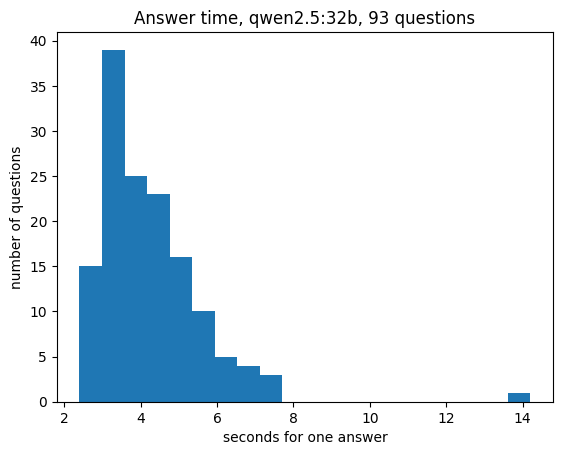

In [20]:
print(check.groupby("language")["seconds"].describe()[["count", "mean", "50%", "max"]].round(1))

plt.hist(check["seconds"], bins=20)
plt.xlabel("seconds for one answer")
plt.ylabel("number of questions")
plt.title("Answer time, qwen2.5:32b, 93 questions")
plt.show()

The one very slow answer is the first question, when Ollama had to load the model into the GPU. The Persian questions take longer because the LLM translates them first, which is a second LLM call.

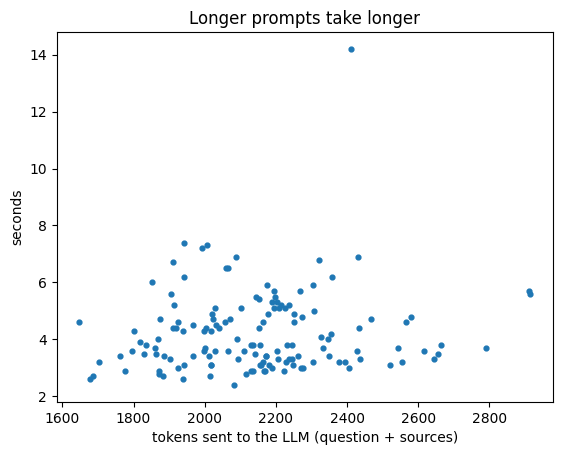

In [21]:
plt.scatter(check["prompt_tokens"], check["seconds"], s=12)
plt.xlabel("tokens sent to the LLM (question + sources)")
plt.ylabel("seconds")
plt.title("Longer prompts take longer")
plt.show()

### Where does the time go?

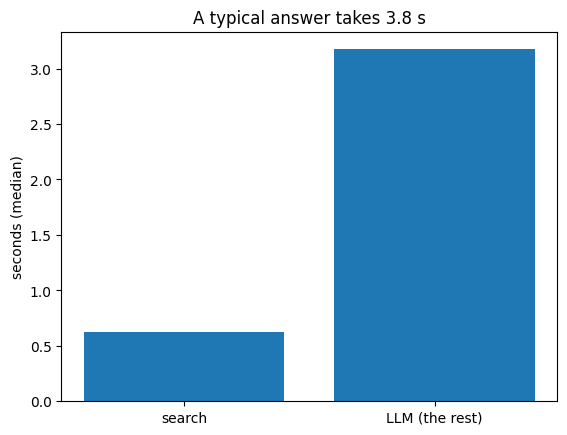

In [22]:
typical = check["seconds"].median()
plt.bar(["search", "LLM (the rest)"], [search_ms.median() / 1000, typical - search_ms.median() / 1000])
plt.ylabel("seconds (median)")
plt.title(f"A typical answer takes {typical:.1f} s")
plt.show()

The search is a small part of the wait. Almost all of the time is the LLM, so a faster GPU or a smaller model is the way to speed things up.

### Many users at once (load tests)

                                       users  concurrency  answered  \
test                                                                  
fake LLM (app only)                    10000          100     10000   
real model (qwen2.5:32b)                 400            8       400   
fake LLM, 10 at once                    2000           10      2000   
fake LLM, 50 at once                    2000           50      2000   
fake LLM, 100 at once                   2000          100      2000   
fake LLM, 200 at once                   2000          200      1995   
fake LLM, 500 at once                   2000          500      1991   
fake LLM, 1000 at once                  2000         1000      1999   
real model (qwen2.5:32b), 32 at once     128           32       128   
real model (qwen2.5:32b), 128 at once    256          128       256   

                                       questions_per_second  median_s   p95_s  \
test                                                              

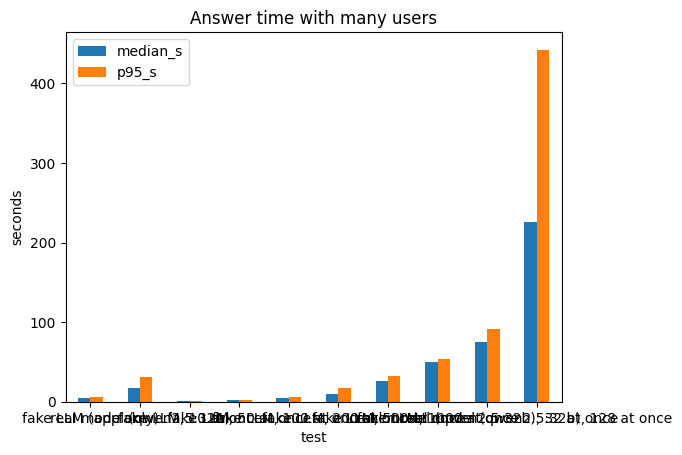

In [23]:
load = pd.read_csv("docs/load_test_results.csv").set_index("test")
print(load[["users", "concurrency", "answered", "questions_per_second", "median_s", "p95_s", "p99_s"]])

load[["median_s", "p95_s"]].plot(kind="bar", rot=0)
plt.ylabel("seconds")
plt.title("Answer time with many users")
plt.show()

With the fake LLM the app answered 10,000 users with no error. With the real model 400 of 400 were answered but each answer waited much longer, because one GPU can only answer about 0.4 questions per second. This is the real limit.

### How good are the answers?

          right passage in the sources  right passage cited  \
language                                                      
English                           97.0                 90.0   
Persian                           92.0                 84.0   

          unanswerable refused  
language                        
English                  100.0  
Persian                  100.0  


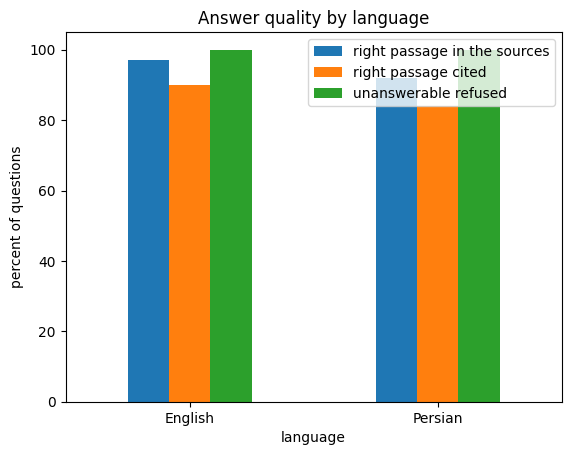

In [24]:
rows = []
for language, part in check.groupby("language"):
    good = part[part["answerable"]]
    bad = part[~part["answerable"]]
    rows.append({
        "language": language,
        "right passage in the sources": 100 * good["evidence_in_sources"].mean(),
        "right passage cited": 100 * good["evidence_cited"].mean(),
        "unanswerable refused": 100 * (~bad["answered"]).mean(),
    })
quality = pd.DataFrame(rows).set_index("language").round(0)
print(quality)

quality.plot(kind="bar", rot=0)
plt.ylabel("percent of questions")
plt.ylim(0, 105)
plt.title("Answer quality by language")
plt.show()

English is solid: the right passage reached the LLM for 56 of 58 questions and was cited for 52, and all 18 unanswerable questions were refused.
Persian is close behind: the right passage reached the LLM for 45 of 49 (92%) and was cited for 41 (84%), and all 16 unanswerable questions were refused.
(Before the search upgrade the Persian numbers were 40 and 34.) Persian has only 49 and 16 questions, so one question moves a bar by 2 to 6 points.

## 13. Search quality at k (hit rate, MRR, nDCG)
These are the usual numbers for the search part of a RAG system. Every question has one right passage, so recall@k is the same as hit@k.
(Precision@5 would be at most 0.2 here, so it says nothing useful.) I use the ranks from section 8; the Persian questions are searched as typed, without the translation step.

In [25]:
import numpy as np

def search_numbers(part):
    got = part["rank"].fillna(999)  # 999 = not in the top 30
    numbers = {f"hit@{k}": (got <= k).mean() for k in (1, 3, 5, 10)}
    numbers["MRR"] = (1 / got).mean()
    numbers["nDCG@10"] = np.where(got <= 10, 1 / np.log2(got + 1), 0).mean()
    return numbers

search_table = pd.DataFrame({
    f"English ({len(english)})": search_numbers(english),
    f"Persian, not translated ({len(persian)})": search_numbers(persian),
}).T.round(3)
search_table

,hit@1,hit@3,hit@5,hit@10,MRR,nDCG@10
English (58),0.741,0.879,0.931,0.966,0.821,0.856
"Persian, not translated (49)",0.653,0.796,0.837,0.857,0.727,0.759


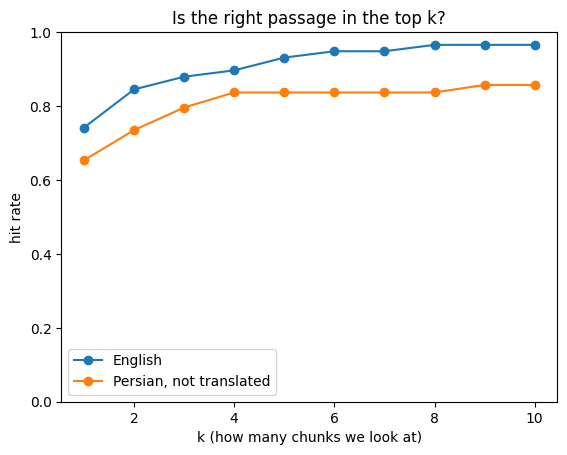

In [26]:
for name, part in [("English", english), ("Persian, not translated", persian)]:
    got = part["rank"].fillna(999)
    plt.plot(range(1, 11), [(got <= k).mean() for k in range(1, 11)], marker="o", label=name)
plt.xlabel("k (how many chunks we look at)")
plt.ylabel("hit rate")
plt.ylim(0, 1)
plt.legend()
plt.title("Is the right passage in the top k?")
plt.show()

In [27]:
persian_checked = check[(check["language"] == "Persian") & check["answerable"]]
print(f"Persian with the translation step: the right passage reached the LLM for "
      f"{persian_checked['evidence_in_sources'].sum()} of {len(persian_checked)} questions")

Persian with the translation step: the right passage reached the LLM for 45 of 49 questions


## 14. Hallucination measures
A made-up answer can look like three different things, so I count each one:
- **Answering when the books have nothing** (34 questions). This is the main number: the model should say "not found".
- **A number in the answer that is in no source.** A wrong dose is the worst case.
- **A citation like [7] when there are only 5 sources.**
- **An LLM judge** that reads the sources and the answer and says SUPPORTED or NOT_SUPPORTED. It is the same model as the answerer, so it can be too kind. I checked it with made-up wrong answers (it caught them), but treat it as a rough signal.

In [28]:
rows = []
for language, part in check.groupby("language"):
    unanswerable = part[~part["answerable"]]
    answered = part[part["answered"]]
    rows.append({
        "language": language,
        "unanswerable questions": len(unanswerable),
        "...that still got an answer": int(unanswerable["answered"].sum()),
        "answers given": len(answered),
        "number in no source": int((answered["made_up_numbers"] > 0).sum()),
        "citation that does not exist": int(answered["bad_citation"].sum()),
        "judge: not backed by the sources": int(answered["judge_supported"].eq(False).sum()),
    })
hallucination = pd.DataFrame(rows).set_index("language")
hallucination.T

language,English,Persian
unanswerable questions,18,16
...that still got an answer,0,0
answers given,58,48
number in no source,0,0
citation that does not exist,0,0
judge: not backed by the sources,0,0


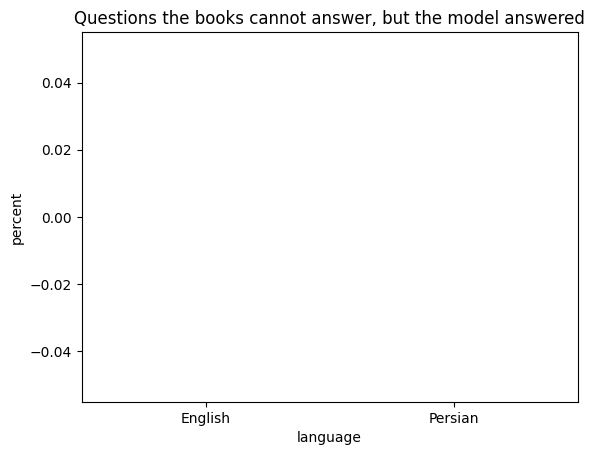

In [29]:
share = 100 * hallucination["...that still got an answer"] / hallucination["unanswerable questions"]
share.plot(kind="bar", rot=0)
plt.ylabel("percent")
plt.title("Questions the books cannot answer, but the model answered")
plt.show()

wrong = check[(~check["answerable"]) & check["answered"]]
for _, row in wrong.iterrows():
    print("\n" + row["question"])
    print(row["answer"][:300])

**Result:** 0 of 18 English and 0 of 16 Persian questions that the books cannot answer got an answer. The other three checks found nothing:
no number outside the sources, no citation that does not exist, and the judge accepted every answer.

Be careful with that: the judge is the same model as the answerer, and a made-up answer can be "faithful" to a real text about another topic, so these checks cannot see every kind of mistake.
The earlier setup had 2 such answers, so the number of unanswerable questions that get an answer is the one to keep watching, ideally with more than 34 questions.

### The same fact in English and in Persian
36 Persian questions ask the same thing as an English one (and 2 older ones match too), so I can compare the languages fact by fact.

38 facts asked in both languages


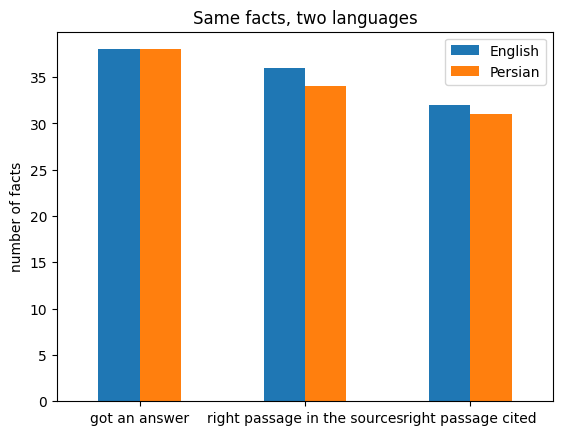

,English,Persian
got an answer,38,38
right passage in the sources,36,34
right passage cited,32,31


In [30]:
check["evidence"] = [item.get("evidence") for item in items]  # same order as the csv
good = check[check["answerable"]].drop_duplicates(["language", "evidence"])
english_side = good[good["language"] == "English"].set_index("evidence")
persian_side = good[good["language"] == "Persian"].set_index("evidence")
same = english_side.index.intersection(persian_side.index)

pairs = pd.DataFrame({
    "English": english_side.loc[same, ["answered", "evidence_in_sources", "evidence_cited"]].sum(),
    "Persian": persian_side.loc[same, ["answered", "evidence_in_sources", "evidence_cited"]].sum(),
})
pairs.index = ["got an answer", "right passage in the sources", "right passage cited"]
print(len(same), "facts asked in both languages")
pairs.plot(kind="bar", rot=0)
plt.ylabel("number of facts")
plt.title("Same facts, two languages")
plt.show()
pairs

Over the 38 facts that were asked in both languages every fact got an answer in both languages, and the right passage was cited 32 times in English and 31 times in Persian.
(Before the search upgrade it was 31 and 26, and Persian refused many questions it could answer.)

## 15. What it would cost with GPT or Claude
The local model has no price per token. To see what a paid API would cost for the same traffic I take the average tokens per question from the real run and multiply them by the prices in `docs/api_prices.csv`. Those prices come from summary websites on the day I looked (the file says which), so check the official price pages before you decide anything.

In [31]:
prices = pd.read_csv("docs/api_prices.csv")
tokens_in = check["prompt_tokens"].mean()
tokens_out = check["completion_tokens"].mean()
print(f"average per question: {tokens_in:.0f} tokens in, {tokens_out:.0f} tokens out")

prices["USD per 1,000 questions"] = (1000 * tokens_in * prices["usd_per_million_input_tokens"]
                                      + 1000 * tokens_out * prices["usd_per_million_output_tokens"]) / 1e6
prices["USD per 10,000 questions"] = prices["USD per 1,000 questions"] * 10
prices[["model", "USD per 1,000 questions", "USD per 10,000 questions"]].round(2)

average per question: 2146 tokens in, 52 tokens out


,model,"USD per 1,000 questions","USD per 10,000 questions"
0,OpenAI GPT-5 mini,0.64,6.40
1,OpenAI GPT-5,3.20,31.98
2,Claude Haiku 4.5,2.40,24.03
3,Claude Sonnet 5,4.81,48.07


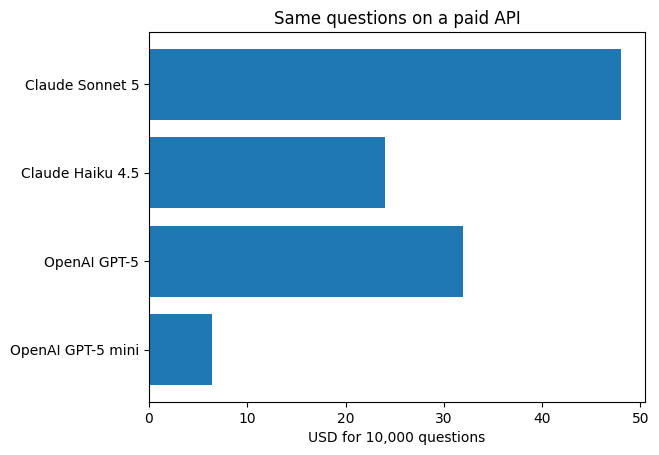

In [32]:
plt.barh(prices["model"], prices["USD per 10,000 questions"])
plt.xlabel("USD for 10,000 questions")
plt.title("Same questions on a paid API")
plt.show()

With about 2,146 tokens in and 52 tokens out per question, 10,000 questions would cost between about USD 6 (GPT-5 mini) and USD 48 (Claude Sonnet 5) on a paid API.
Persian questions need one more small call for the translation, and the judge calls are not counted. The prices come from summary websites and can be out of date.

The local model costs nothing per token, but it needs a GPU server: about 7 hours of one A100 for 10,000 questions. A paid API also answers many users at the same time,
so it is faster when many people ask together. The price of the local setup is speed; the price of the API is that every question leaves your own network.

## 16. What happens when the number of users grows?
First the app with the fake LLM (so only the app is tested), from 10 up to 1,000 users at the same moment. Then the real model, where one GPU is the limit.

In [33]:
load = pd.read_csv("docs/load_test_results.csv")
sweep = load[load["test"].str.startswith("fake LLM,")].sort_values("concurrency")
sweep[["test", "users", "answered", "questions_per_second", "median_s", "p95_s"]]

,test,users,answered,questions_per_second,median_s,p95_s
2,"fake LLM, 10 at once",2000,2000,9.5,1.05,1.09
3,"fake LLM, 50 at once",2000,2000,22.2,2.22,2.72
4,"fake LLM, 100 at once",2000,2000,21.5,4.53,5.52
5,"fake LLM, 200 at once",2000,1995,19.8,9.35,17.71
6,"fake LLM, 500 at once",2000,1991,19.4,25.47,32.89
7,"fake LLM, 1000 at once",2000,1999,19.3,49.85,53.80


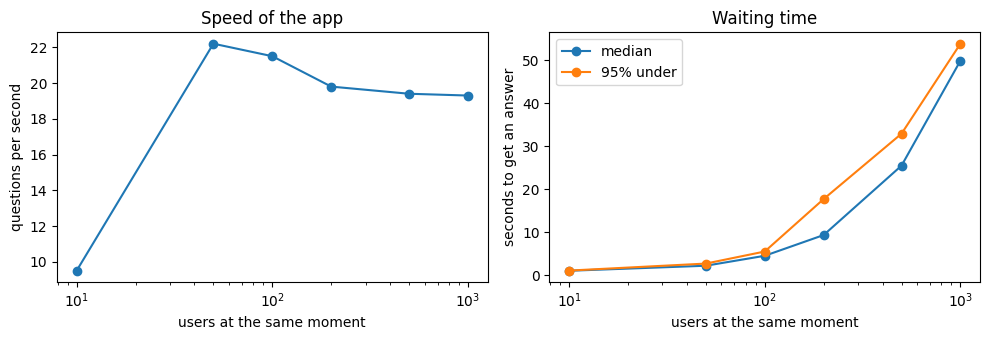

In [34]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.5))
left.plot(sweep["concurrency"], sweep["questions_per_second"], marker="o")
left.set_xscale("log")
left.set_xlabel("users at the same moment")
left.set_ylabel("questions per second")
left.set_title("Speed of the app")
right.plot(sweep["concurrency"], sweep["median_s"], marker="o", label="median")
right.plot(sweep["concurrency"], sweep["p95_s"], marker="o", label="95% under")
right.set_xscale("log")
right.set_xlabel("users at the same moment")
right.set_ylabel("seconds to get an answer")
right.legend()
right.set_title("Waiting time")
plt.tight_layout()
plt.show()

The app does about 20 questions per second. Up to about 50 users at the same moment the wait is just the 1 second of the fake model plus a small queue. After that more users
don't make it faster, they only wait longer: the median wait is roughly the number of users divided by 20 (100 users: 4.5 s, 1,000 users: 50 s).

At 200 users and more, between 1 and 9 requests out of 2,000 (at most 0.5%) were dropped with a `ReadError`, a connection that closed while it was waiting.
The app itself logged no error. My guess is a connection the server closed while the test client was still reusing it, but I did not prove that.


### With the real model
One A100 gives about 0.4 answers per second. If many users ask at the same moment they stand in a queue, so the waiting time is roughly **users at the same moment ÷ 0.4** seconds. The dots are the runs I measured, the lines show the same rule for more GPUs (this is a calculation, I only had one GPU for this).

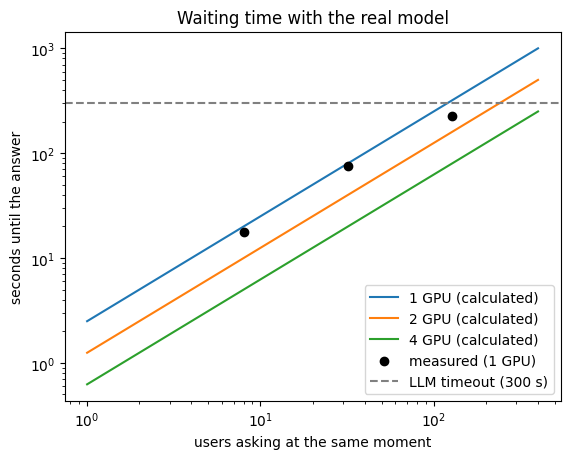

,test,users,concurrency,answered,questions_per_second,median_s,p95_s
1,real model (qwen2.5:32b),400,8,400,0.4,17.83,31.58
8,"real model (qwen2.5:32b), 32 at once",128,32,128,0.4,75.15,91.34
9,"real model (qwen2.5:32b), 128 at once",256,128,256,0.4,225.82,442.25


In [35]:
speed_one_gpu = 0.4
users_now = np.array([1, 2, 5, 10, 20, 50, 100, 200, 400])
for gpus in (1, 2, 4):
    plt.plot(users_now, users_now / (speed_one_gpu * gpus), label=f"{gpus} GPU (calculated)")
real = load[load["test"].str.startswith("real model")]
plt.scatter(real["concurrency"], real["median_s"], color="black", zorder=5, label="measured (1 GPU)")
plt.axhline(300, linestyle="--", color="gray", label="LLM timeout (300 s)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("users asking at the same moment")
plt.ylabel("seconds until the answer")
plt.title("Waiting time with the real model")
plt.legend()
plt.show()
real[["test", "users", "concurrency", "answered", "questions_per_second", "median_s", "p95_s"]]

The real runs follow the rule: 8 users at once wait 18 s, 32 users wait 75 s (the rule says 80 s), and with 128 users the median wait is 226 s and the slowest waited 442 s.
Everything was answered and nothing failed, but no doctor would wait 7 minutes.

So the question is not how many users the app can hold, it is how many answers per second the GPU can make: about 0.4. If 20 doctors asked at the very same moment,
the median wait would be about 50 s. More GPUs, a smaller model or a faster model server (for example vLLM) would help; the app is not the problem.

## 17. Patient questions
A second test, with 525 questions that patients might ask (`data/eval/patient_questions_english_persian_525.csv`), in English and in Persian. The csv has questions and the web pages they should be answered from, but **no reference answers**, so I can't say "this answer is right". I can measure other things: does it answer or say "I don't know", does it cite the page the dataset names, are the numbers in the sources, and does an LLM judge find the answer backed by the sources.

Q001 to Q500 are 25 diseases times the same 20 question types, so they test topic coverage, not 500 different patients. I downloaded the named pages from MedlinePlus, NHS, WHO, NIMH and NIDDK into a separate knowledge base (25 pages). CDC blocked the download (flu, COVID, stroke) and one NHS page had no text (breast cancer), so those topics have no page. Their questions, and the 50 forum-style questions, are the "open" questions: the right answer for most of them is "I don't know".

In [36]:
def patient_answers(name):
    rows = pd.read_csv(f"docs/patient_check_{name}.csv")
    # the app now shows "I don't know" when the model writes NO_ANSWER anywhere, so I count it like that too
    rows["answered"] = rows["answered"] & ~rows["answer"].str.contains("NO_ANSWER", case=False, na=False)
    return rows

patients = {"English": patient_answers("en"), "Persian": patient_answers("fa")}
broken_letters = "[\u3040-\u30ff\u3400-\u9fff\uac00-\ud7af]"  # Chinese, Japanese, Korean

rows = []
for language, part in patients.items():
    given = part[part["answered"]]
    rows.append({
        "language": language,
        "questions": len(part),
        "answered": len(given),
        "said I don't know": len(part) - len(given),
        "cited the expected page": int(given["evidence_cited"].sum()),
        "number in no source": int((given["made_up_numbers"] > 0).sum()),
        "judge: not backed": int(given["judge_supported"].eq(False).sum()),
        "broken letters": int(given["answer"].str.contains(broken_letters).sum()),
        "median seconds": round(part["seconds"].median(), 1),
    })
patient_table = pd.DataFrame(rows).set_index("language")
patient_table.T

language,English,Persian
questions,420.0,420.0
answered,297.0,314.0
said I don't know,123.0,106.0
cited the expected page,293.0,305.0
number in no source,1.0,2.0
judge: not backed,20.0,84.0
broken letters,0.0,0.0
median seconds,5.1,5.8


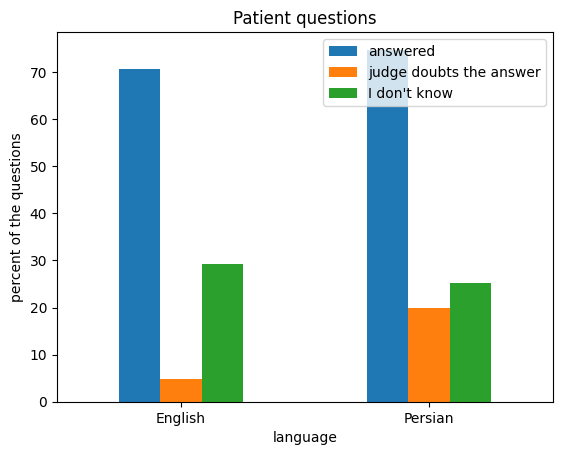

In [37]:
share = pd.DataFrame({
    "answered": patient_table["answered"] / patient_table["questions"],
    "judge doubts the answer": patient_table["judge: not backed"] / patient_table["questions"],
    "I don't know": patient_table["said I don't know"] / patient_table["questions"],
}) * 100
share.plot(kind="bar", rot=0)
plt.ylabel("percent of the questions")
plt.title("Patient questions")
plt.show()

**English:** 71% answered, 29% "I don't know". When it answers, 99% of the answers cite the page the dataset names, and every answer has a citation. 1 answer has a number that is in no source and the judge doubts 7% (20).

**Persian:** 75% answered, and 97% of the answers cite the expected page. It is still the weaker language: the judge doubts 27% of the answers (84), and 2 have a number that is in no source.
The app hides any answer with Chinese, Japanese or Korean letters behind "I don't know". The judge is the same model that wrote the answers and it reads Persian worse than English, so treat the Persian doubts as a warning, not as an exact number.
The better search did not fix this: retrieval is fine (the expected page reached the LLM for 415 of 420 questions), the weak part is how the LLM writes Persian.
I also tried Gemma 3 12B for Persian: it was about as good on the staff questions and about 1.4 times faster, but it made up 3 of the 18 English unanswerable answers, so I kept Qwen.
(The times in the table are higher than in section 18, because three runs shared the GPU.)

**Open questions:** 187 of 210 got "I don't know". The 23 answers came from nearby pages (for example the asthma page does talk about flu), so they are grounded, but not an answer to what was asked.

### Which kinds of question get "I don't know"?

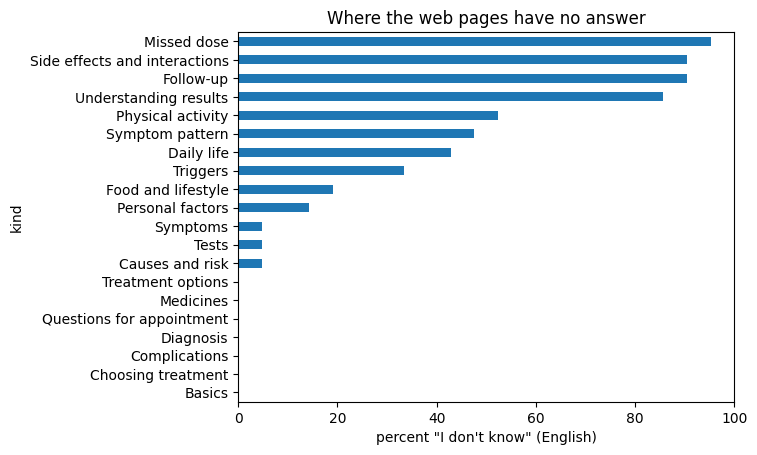

In [38]:
import json

plan = pd.read_csv("data/eval/patient_questions_english_persian_525.csv")
kind = dict(zip(plan["Question ID"], plan["Question intent"]))
ids = [json.loads(line)["id"] for line in open("data/eval/patient_questions_en.jsonl", encoding="utf-8")]
english = patients["English"]
english = english.assign(kind=[kind[i] for i in ids])
unknown = (1 - english.groupby("kind")["answered"].mean()).sort_values() * 100
unknown.plot(kind="barh")
plt.xlabel("percent \"I don't know\" (English)")
plt.title("Where the web pages have no answer")
plt.show()

The web pages explain a disease well, but they say little about what to do after a missed dose (95% "I don't know"), follow-up visits and side effects (90% each) or how to ask a doctor about a test result (86%). For those questions the honest answer is "I don't know", which is correct but makes the answers feel thin.
They would need more pages (or a text written by a doctor).

In [39]:
open_questions = patient_answers("open")
print(len(open_questions), "open questions:", int((~open_questions["answered"]).sum()), "got \"I don't know\",",
      int(open_questions["answered"].sum()), "got an answer")

210 open questions: 187 got "I don't know", 23 got an answer


## 18. Where does the time go?
`python -m scripts.time_steps` runs a question step by step and times each step (30 English and 30 Persian questions, one at a time, results in `docs/time_steps.csv`). The model server (Ollama) also tells how long it needed to read the sources and to write the answer.

In [40]:
steps = pd.read_csv("docs/time_steps.csv")
medians = steps.groupby("language").median(numeric_only=True)
medians["total"] = medians.sum(axis=1)
medians.T.round(1)

language,English,Persian
translate,0.0,908.5
embed question,22.8,23.9
dense search,0.8,1.0
BM25 search,18.9,25.5
merge + rerank,584.8,589.2
build prompt,0.1,0.1
LLM: load model,2.9,2.8
LLM: read the sources,1653.0,1660.1
LLM: write the answer,1120.9,1721.6
total,3404.4,4932.7


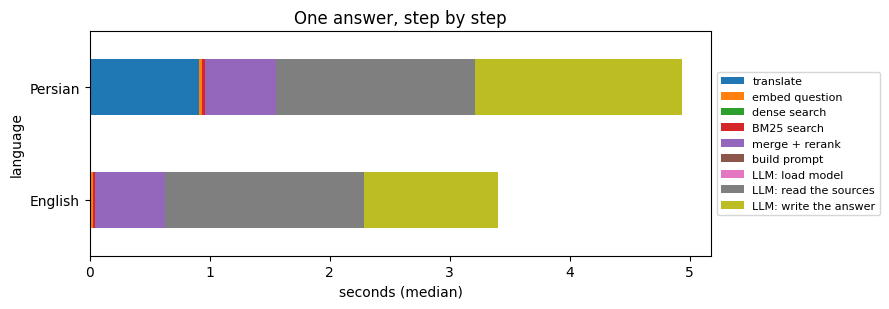

In [41]:
parts = medians.drop(columns="total") / 1000
parts.plot(kind="barh", stacked=True, figsize=(9, 3.2))
plt.xlabel("seconds (median)")
plt.title("One answer, step by step")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

In [42]:
share_of_time = (100 * medians.drop(columns="total").div(medians["total"], axis=0)).round(1)
share_of_time.T.sort_values("English", ascending=False).head(4)

language,English,Persian
LLM: read the sources,48.6,33.7
LLM: write the answer,32.9,34.9
merge + rerank,17.2,11.9
embed question,0.7,0.5


**What takes the time:** the LLM, as before, but the search is not free anymore. For an English question (3.4 s in total) reading the sources takes 49% (about 1.65 s), writing the answer 33% (about 1.1 s)
and the reranker 17% (about 0.6 s). Embedding, dense search and BM25 together take about 40 milliseconds, around 1%. A Persian question (4.9 s) also needs a translation call, another 0.9 s (18%).

**What to optimize, in this order:**
1. **Reading the sources:** every question sends 5 chunks (about 2,100 tokens). Shorter chunks would cut this part: the tuner prefers 150 words, and with the reranker the search found the right passage almost as often (0.90 against 0.91 in the top 5 for English), so it is worth an end-to-end test (I tested only the search).
2. **Writing the answer:** a faster or smaller model, or a faster model server such as vLLM. The shorter-answer prompt already cut about 10% of the answer tokens.
3. **The reranker (0.6 s):** a smaller reranker or looking at 10 chunks instead of 20 would roughly halve it (not tested). It is worth its price: it lifted the right passage in the top 5 from 77% to 89%.
4. **Translation of Persian questions:** a small translation model, or a cache for repeated questions.

(The English total of 3.4 s is close to the 3.7 s average of the answer check.)

## 19. What I changed to make it better and safer
The tests found problems and room to improve. I tried each idea on the same questions and kept only what helped.

What I kept:
- The embedding model bge-m3 instead of multilingual-e5-base, and a reranker (BAAI/bge-reranker-v2-m3) for the best 20 chunks. The right passage in the top 5 went from 77% to 89% over all questions, and for Persian questions typed in Persian from 31% to 84%. Both are just settings (`EMBEDDING_MODEL`, `RERANK_MODEL`), and the reranker is a few lines in the retriever.
- A shorter prompt ("start with the direct answer, 2 to 4 short sentences, simple words"). Same quality, answers about 10% shorter (English 11%, the Persian ones didn't get shorter).
- A last line in the message to the model, "Write the answer in Persian" or "in English". Some models (Gemma) answered Persian questions in English without it.
- A fix for the word NO_ANSWER leaking into 10 English answers. The model explained first and wrote it at the end, and the app only looked at the start of the reply. Now a reply that contains it anywhere becomes the "I don't know" message.
- An emergency line. If the question has an urgent word (chest pain, trouble breathing, heavy bleeding, suicide), the answer starts with a line telling the person to call the emergency number (115 in Iran). The word list is short on purpose and a clinician should review it. The disclaimer of every answer also mentions the emergency number.
- A guard for broken Persian: if an answer to a Persian question has Chinese, Japanese or Korean letters in it, the app shows "I don't know" instead.
- Prometheus alerts (`docs/alerts.yml`) and a sheet for doctors (`python -m scripts.review_sample`) with 100 answers and empty columns for "correct?" and "safe for a patient?".

What I tried and dropped: a bigger e5 model (worse for English), removing page headers, joining words the PDF broke, adding the book title to every chunk, a prompt that answers part of a question (it cited the right page less often), and Gemma 3 12B instead of Qwen (it made up answers).

In [43]:
from app.rag import looks_urgent

for question in ["I have chest pain, what should I do?", "درد قفسه سینه دارم", "How is COPD diagnosed?"]:
    print(looks_urgent(question), "|", question)

True | I have chest pain, what should I do?
True | درد قفسه سینه دارم
False | How is COPD diagnosed?


In [44]:
review = pd.read_csv("docs/doctor_review.csv")
print(len(review), "answers for the doctors,", review["language"].value_counts().to_dict())
review[["id", "language", "question", "source"]].head(3)

100 answers for the doctors, {'en': 50, 'fa': 50}


,id,language,question,source
0,Q163,en,Can symptoms linked to Anxiety disorders come ...,MedlinePlus Anxiety disorders; NIMH Anxiety di...
1,Q464,en,What factors can increase a person's chance of...,MedlinePlus Hay fever
2,Q114,en,"How could Arthritis affect my sleep, work, stu...",NHS Arthritis


## 20. What is left to do
The search and the answers are in good shape. These are the open points:

| Part | State |
|---|---|
| Tests, CI, metrics, dashboard, alerts, load test | done |
| "I don't know" and citations | done: 99% of English and 97% of Persian patient answers cite the expected page; no unanswerable staff question was answered |
| Search quality | much better: right passage in the top 5 for 89% of the questions |
| Emergency line, broken-text guard | done, a simple word list, a clinician should review it |
| A doctor reads the answers | **not done**: the sheet is ready, someone has to fill it in |
| Persian quality | **still weaker**: the judge doubts 27% of the Persian patient answers (English 7%); the weak part is the LLM's Persian |
| Missing pages (flu, COVID, stroke, breast cancer) | **not done** (CDC blocks downloads, ask for the text or use another source) |
| Page licences | **not checked**: check every site before using its pages |
| Capacity | one GPU makes about 0.4 answers per second: 20 users at the same moment wait about 50 s |

## 21. Run the tests

In [45]:
run = subprocess.run([sys.executable, "-m", "pytest", "-q"], capture_output=True, text=True)
print("\n".join(run.stdout.strip().splitlines()[-6:]))
print("exit code:", run.returncode)

........................................................................ [ 59%]
.................................................                        [100%]
121 passed in 3.18s
exit code: 0


## 22. What I take from this
The biggest search gain came from the embedding model and the reranker, not from the chunking. The right passage is now in the top 5 for 89% of the questions (hybrid alone 77%, with the first embedding model 75%). Hybrid still beats dense alone and BM25 alone, and I tried three ingestion ideas that did nothing.

English works. On the guideline questions the right passage reached the LLM for 56 of 58 questions and was cited for 52, and all 18 questions the books can't answer got "I don't know". Persian is much better than at the start (typed in Persian, the right passage is in the top 5 for 84% instead of 31%, 41 of 49 answers cite it, and no unanswerable question got an answer), but the LLM's Persian is still the weak part. The judge doubts 27% of the Persian patient answers.

For the patient questions, about 7 in 10 get an answer that cites the right page (English 71%, Persian 75%) and the rest get "I don't know". The pages say little about missed doses, follow-up and test results.

An English answer takes 3.4 s: 49% reading the sources, 33% writing the answer, 17% the reranker. The search itself (embedding, dense, BM25) is about 40 ms. On a paid API, 10,000 questions would cost about $6 to $48. The local model has no token price but needs a GPU: roughly 7 hours of one A100 for 10,000 questions.

The app alone handles about 20 questions per second. The limit is the GPU at about 0.4 answers per second, so the waiting time is about the number of users divided by 0.4.

I should be careful with all of this. I wrote the 141 questions myself from the book sentences, the test split is small, the API prices come from summary websites, and no doctor has read the answers yet.